## TUGAS 4 RINGKASAN DOKUMEN

Prio Budi Laksono

210411100177

Preprocessing hasil scraping data dari kompas.com

In [13]:
import string
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import csv

# URL dari artikel Berita di IDN Times
url = 'https://nasional.kompas.com/read/2024/11/05/13351201/dilantik-jadi-komisioner-kpu-iffa-rosita-ungkap-beban-kerjanya-makin-luas'

# Membuat permintaan ke URL
response = requests.get(url)

# Inisialisasi data yang akan disimpan
# Mengambil ulang dan membersihkan data yang diminta
artikel_mees = []

if response.status_code == 200:
    # Parsing halaman web
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Mengambil judul artikel
    title = soup.find('h1').get_text().strip()
    
    # Mengambil tanggal publikasi artikel dan membersihkan spasi berlebih

    date_tag = soup.find('div', class_='videoKG-date')
    if not date_tag:
        # Jika tidak ditemukan, ambil dari div dengan class 'read__time'
        date_tag = soup.find('div', class_='read__time')
    
    date = date_tag.text.strip().split('-')[-1].strip() if date_tag else 'Tidak ada tanggal'
    
    # Mengambil isi artikel dengan membersihkan konten tambahan
    content_div = soup.find('div', class_='read__content')
    article_text = ' '.join([p.text for p in content_div.find_all('p')]) if content_div else 'Tidak ada isi berita'

    # Simpan data dalam bentuk dictionary yang telah dibersihkan
    artikel_mees.append({
        'Title': title,
        'Date': date,
        'Content': article_text
    })

# Membuat dataframe dari data yang telah dibersihkan
data_mees = pd.DataFrame(artikel_mees)

# Menampilkan dataframe yang bersih
data_mees

,Title,Date,Content
0,"Dilantik Jadi Komisioner KPU, Iffa Rosita Ungk...","05/11/2024, 13:35 WIB","JAKARTA, KOMPAS.com - Anggota Komisioner Komis..."


## CASE FOLDING
Merubah content menjadi huruf kecil semua untuk memudahkan pada saat training data nanti

In [14]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
# Proses case folding
def casefolding(Content):
    if isinstance(Content, list):
        # Jika Content adalah list, terapkan case folding pada setiap elemen
        return [str(item).lower() for item in Content]
    else:
        # Jika Content adalah string, langsung terapkan case folding
        return str(Content).lower()

# Terapkan fungsi casefolding pada kolom 'Content'
data_mees['Content'] = data_mees['Content'].apply(casefolding)

data_mees.head()

,Title,Date,Content
0,"Dilantik Jadi Komisioner KPU, Iffa Rosita Ungk...","05/11/2024, 13:35 WIB","jakarta, kompas.com - anggota komisioner komis..."


## Menyimpan Data

In [17]:
csv_filename = "1artikel_kompas.csv"
data_mees.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"Data berita telah disimpan ke {csv_filename}")

data_mees = pd.read_csv("1artikel_kompas.csv", sep=',', encoding='latin1')
data_mees.head()

Data berita telah disimpan ke 1artikel_kompas.csv


,Title,Date,Content
0,"Dilantik Jadi Komisioner KPU, Iffa Rosita Ungk...","05/11/2024, 13:35 WIB","jakarta, kompas.com - anggota komisioner komis..."


## Cleansing Data

In [19]:
def cleansing(Content):
    # Menghapus whitespace di awal dan akhir teks
    Content = Content.strip()
    
    # Menghapus tanda baca dan karakter khusus
    Content = re.sub(f"[{string.punctuation}]", '', Content)
    
    # Menghapus angka
    Content = re.sub(r'\d+', '', Content)
    
    # Menghapus huruf tunggal (opsional, tergantung kebutuhan)
    Content = re.sub(r"\b[a-zA-Z]\b", "", Content)
    
    # Menghapus karakter-karakter non-standar seperti â
    Content = re.sub(r'[^\x00-\x7F]+', '', Content)
    
    # Menghapus spasi ganda
    Content = re.sub(r'\s+', ' ', Content)
    
    return Content

# Terapkan fungsi cleansing pada kolom 'Content'
data_mees['Content'] = data_mees['Content'].apply(cleansing)

# Menampilkan 5 baris pertama
data_mees.head(5)

,Title,Date,Content
0,"Dilantik Jadi Komisioner KPU, Iffa Rosita Ungk...","05/11/2024, 13:35 WIB",jakarta kompascom anggota komisioner komisi pe...


## Tokenisasi 
Memecah konten menjadi perkata

In [20]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
import pandas as pd  # Ensure you import pandas for DataFrame usage

# Download required resources
nltk.download('punkt')
nltk.download('punkt_tab')

# Ekstraksi kalimat dari konten artikel
sentences = sent_tokenize(article_text)

# Tokenisasi tiap kalimat menjadi term
terms_per_sentence = [word_tokenize(sentence) for sentence in sentences]

# Membuat objek yang menyimpan hasil term dari setiap kalimat
extracted_terms = [{'Sentence': sentence, 'Terms': terms} for sentence, terms in zip(sentences, terms_per_sentence)]

# Menampilkan hasilnya sebagai dataframe
df_terms = pd.DataFrame(extracted_terms)

# Menampilkan dataframe
print(df_terms)


                                             Sentence  \
0   JAKARTA, KOMPAS.com - Anggota Komisioner Komis...   
1   Iffa mengucapkan syukur atas amanah dan keperc...   
2   "Kalau sebelumnya beban kerja saya hanya di wi...   
3   Saya harus mengkoordinir 38 provinsi bersama t...   
4   KOMPAS.com/FIKA NURUL ULYA Anggota Komisioner ...   
5   Baca juga: Prabowo Lantik Iffa Rosita Jadi Kom...   
6   Menurutnya, tugas utama saat ini adalah memast...   
7            "Intinya penguatan di kolektif kolegial.   
8   Kemudian di tahapan Pilkada 2024, kita harap s...   
9   Iffa berharap Pilkada 2024 dapat berjalan deng...   
10  "Doakan semoga saya dan kawan-kawan yang lain ...   
11  Baca juga: Anggota KPU Kaltim Iffa Rosita Dise...   
12  Mellaz berharap pengelolaan Pemilu dan Pilkada...   
13  "Tentu saja dengan dilantiknya Ibu Iffa menjad...   
14  Sebelumnya, Prabowo Subianto melantik Iffa Ros...   
15  Pelantikan ini dilakukan berdasarkan Keputusan...   

                              

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pblak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pblak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## PROSES TF IDF
TF-IDF (Term Frequency-Inverse Document Frequency) adalah suatu teknik yang umum digunakan dalam pemrosesan bahasa alami (NLP) dan analisis teks untuk mengukur pentingnya suatu kata dalam sebuah dokumen

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import sent_tokenize, word_tokenize

# Assuming we have the article_text
sentences = sent_tokenize(article_text)
terms_per_sentence = [word_tokenize(sentence) for sentence in sentences]
extracted_terms = [{'Sentence': sentence, 'Terms': terms} for sentence, terms in zip(sentences, terms_per_sentence)]
df_terms = pd.DataFrame(extracted_terms)

# Menggabungkan terms menjadi string untuk setiap kalimat
df_terms['Terms_String'] = df_terms['Terms'].apply(' '.join)

# Membuat TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit dan transform data
tfidf_matrix = tfidf_vectorizer.fit_transform(df_terms['Terms_String'])

# Mendapatkan nama-nama feature (terms)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Membuat DataFrame untuk nilai TF-IDF
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# Menambahkan kolom Sentence
tfidf_df['Sentence'] = df_terms['Sentence']

# Melelehkan (melting) DataFrame untuk format yang lebih mudah dibaca
melted_tfidf = tfidf_df.melt(id_vars=['Sentence'], var_name='Term', value_name='TF-IDF')

# Menghapus baris dengan nilai TF-IDF 0
melted_tfidf = melted_tfidf[melted_tfidf['TF-IDF'] != 0]

# Mengurutkan berdasarkan nilai TF-IDF tertinggi
melted_tfidf = melted_tfidf.sort_values('TF-IDF', ascending=False)

# Menampilkan hasil
print(melted_tfidf)

                                               Sentence       Term    TF-IDF
2359           "Intinya penguatan di kolektif kolegial.  penguatan  0.483852
1479           "Intinya penguatan di kolektif kolegial.   kolektif  0.483852
1015           "Intinya penguatan di kolektif kolegial.    intinya  0.483852
1463           "Intinya penguatan di kolektif kolegial.   kolegial  0.483852
2979  Saya harus mengkoordinir 38 provinsi bersama t...      teman  0.473077
...                                                 ...        ...       ...
3212  Mellaz berharap pengelolaan Pemilu dan Pilkada...       yang  0.103650
213   Baca juga: Prabowo Lantik Iffa Rosita Jadi Kom...    anggota  0.097804
973   "Tentu saja dengan dilantiknya Ibu Iffa menjad...       iffa  0.097609
3211  Baca juga: Anggota KPU Kaltim Iffa Rosita Dise...       yang  0.085723
968   Kemudian di tahapan Pilkada 2024, kita harap s...       iffa  0.078167

[353 rows x 3 columns]


## PROSES COSINE SIMILARITY
Cosine similarity adalah ukuran untuk menghitung seberapa mirip dua vektor dalam ruang vektor, dengan mengukur sudut antara kedua vektor tersebut. Dalam konteks pemrosesan teks, cosine similarity sering digunakan untuk menghitung seberapa mirip dua dokumen atau kalimat berdasarkan representasi vektornya, misalnya setelah diubah menjadi vektor TF-IDF (Term Frequency-Inverse Document Frequency).

In [47]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Menghitung cosine similarity (asumsi df_terms sudah ada dan tfidf_matrix sudah dihitung)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Mengubah cosine similarity menjadi DataFrame untuk visualisasi
cosine_sim_df = pd.DataFrame(cosine_sim, index=df_terms['Sentence'], columns=df_terms['Sentence'])


In [48]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine

# Assuming we have the melted_tfidf DataFrame from the previous code
# If not, uncomment and run the previous code to get melted_tfidf

# Step 1: Pivot the melted DataFrame back to wide format
tfidf_wide = melted_tfidf.pivot(index='Sentence', columns='Term', values='TF-IDF').fillna(0)

# Step 2: Calculate cosine similarity between sentences
num_sentences = len(tfidf_wide)
adjacency_matrix = np.zeros((num_sentences, num_sentences))

for i in range(num_sentences):
    for j in range(i, num_sentences):  # We only need to calculate upper triangle
        if i == j:
            adjacency_matrix[i][j] = 1.0  # Sentence is fully similar to itself
        else:
            similarity = 1 - cosine(tfidf_wide.iloc[i], tfidf_wide.iloc[j])
            adjacency_matrix[i][j] = similarity
            adjacency_matrix[j][i] = similarity  # Matrix is symmetric

# Create a DataFrame for better visualization
adjacency_df = pd.DataFrame(adjacency_matrix, 
                            index=tfidf_wide.index, 
                            columns=tfidf_wide.index)

# Display the adjacency matrix
print(adjacency_df)

# Optional: You can set a threshold to consider only strong connections
threshold = 0.5
adjacency_df_thresholded = adjacency_df.where(adjacency_df > threshold, 0)

print("\nAdjacency Matrix (with threshold):")

Sentence                                            "Doakan semoga saya dan kawan-kawan yang lain di KPU RI bisa menuntaskan masa jabatan kami dengan baik dengan khusnul khotimah," harapnya.  \
Sentence                                                                                                                                                                                         
"Doakan semoga saya dan kawan-kawan yang lain d...                                           1.000000                                                                                            
"Intinya penguatan di kolektif kolegial.                                                     0.030612                                                                                            
"Kalau sebelumnya beban kerja saya hanya di wil...                                           0.063100                                                                                            
"Tentu saja dengan dilantiknya

In [49]:
#Convert cosine similarity to binary values (0 or 1) based on threshold
binary_threshold = 0.5  # Threshold untuk memutuskan apakah similarity cukup kuat
adjacency_df_binary = adjacency_df.applymap(lambda x: 1 if x >= binary_threshold else 0)

C:\Users\pblak\AppData\Local\Temp\ipykernel_125468\1611741122.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency_df_binary = adjacency_df.applymap(lambda x: 1 if x >= binary_threshold else 0)


## Menghitung Degree Centrality dan menggambar graf
Degree centrality adalah salah satu ukuran dalam teori graf yang digunakan untuk mengukur seberapa penting atau terhubungnya sebuah simpul (node) dalam graf. Secara khusus, degree centrality mengacu pada jumlah edge (hubungan) yang terhubung langsung ke sebuah simpul.

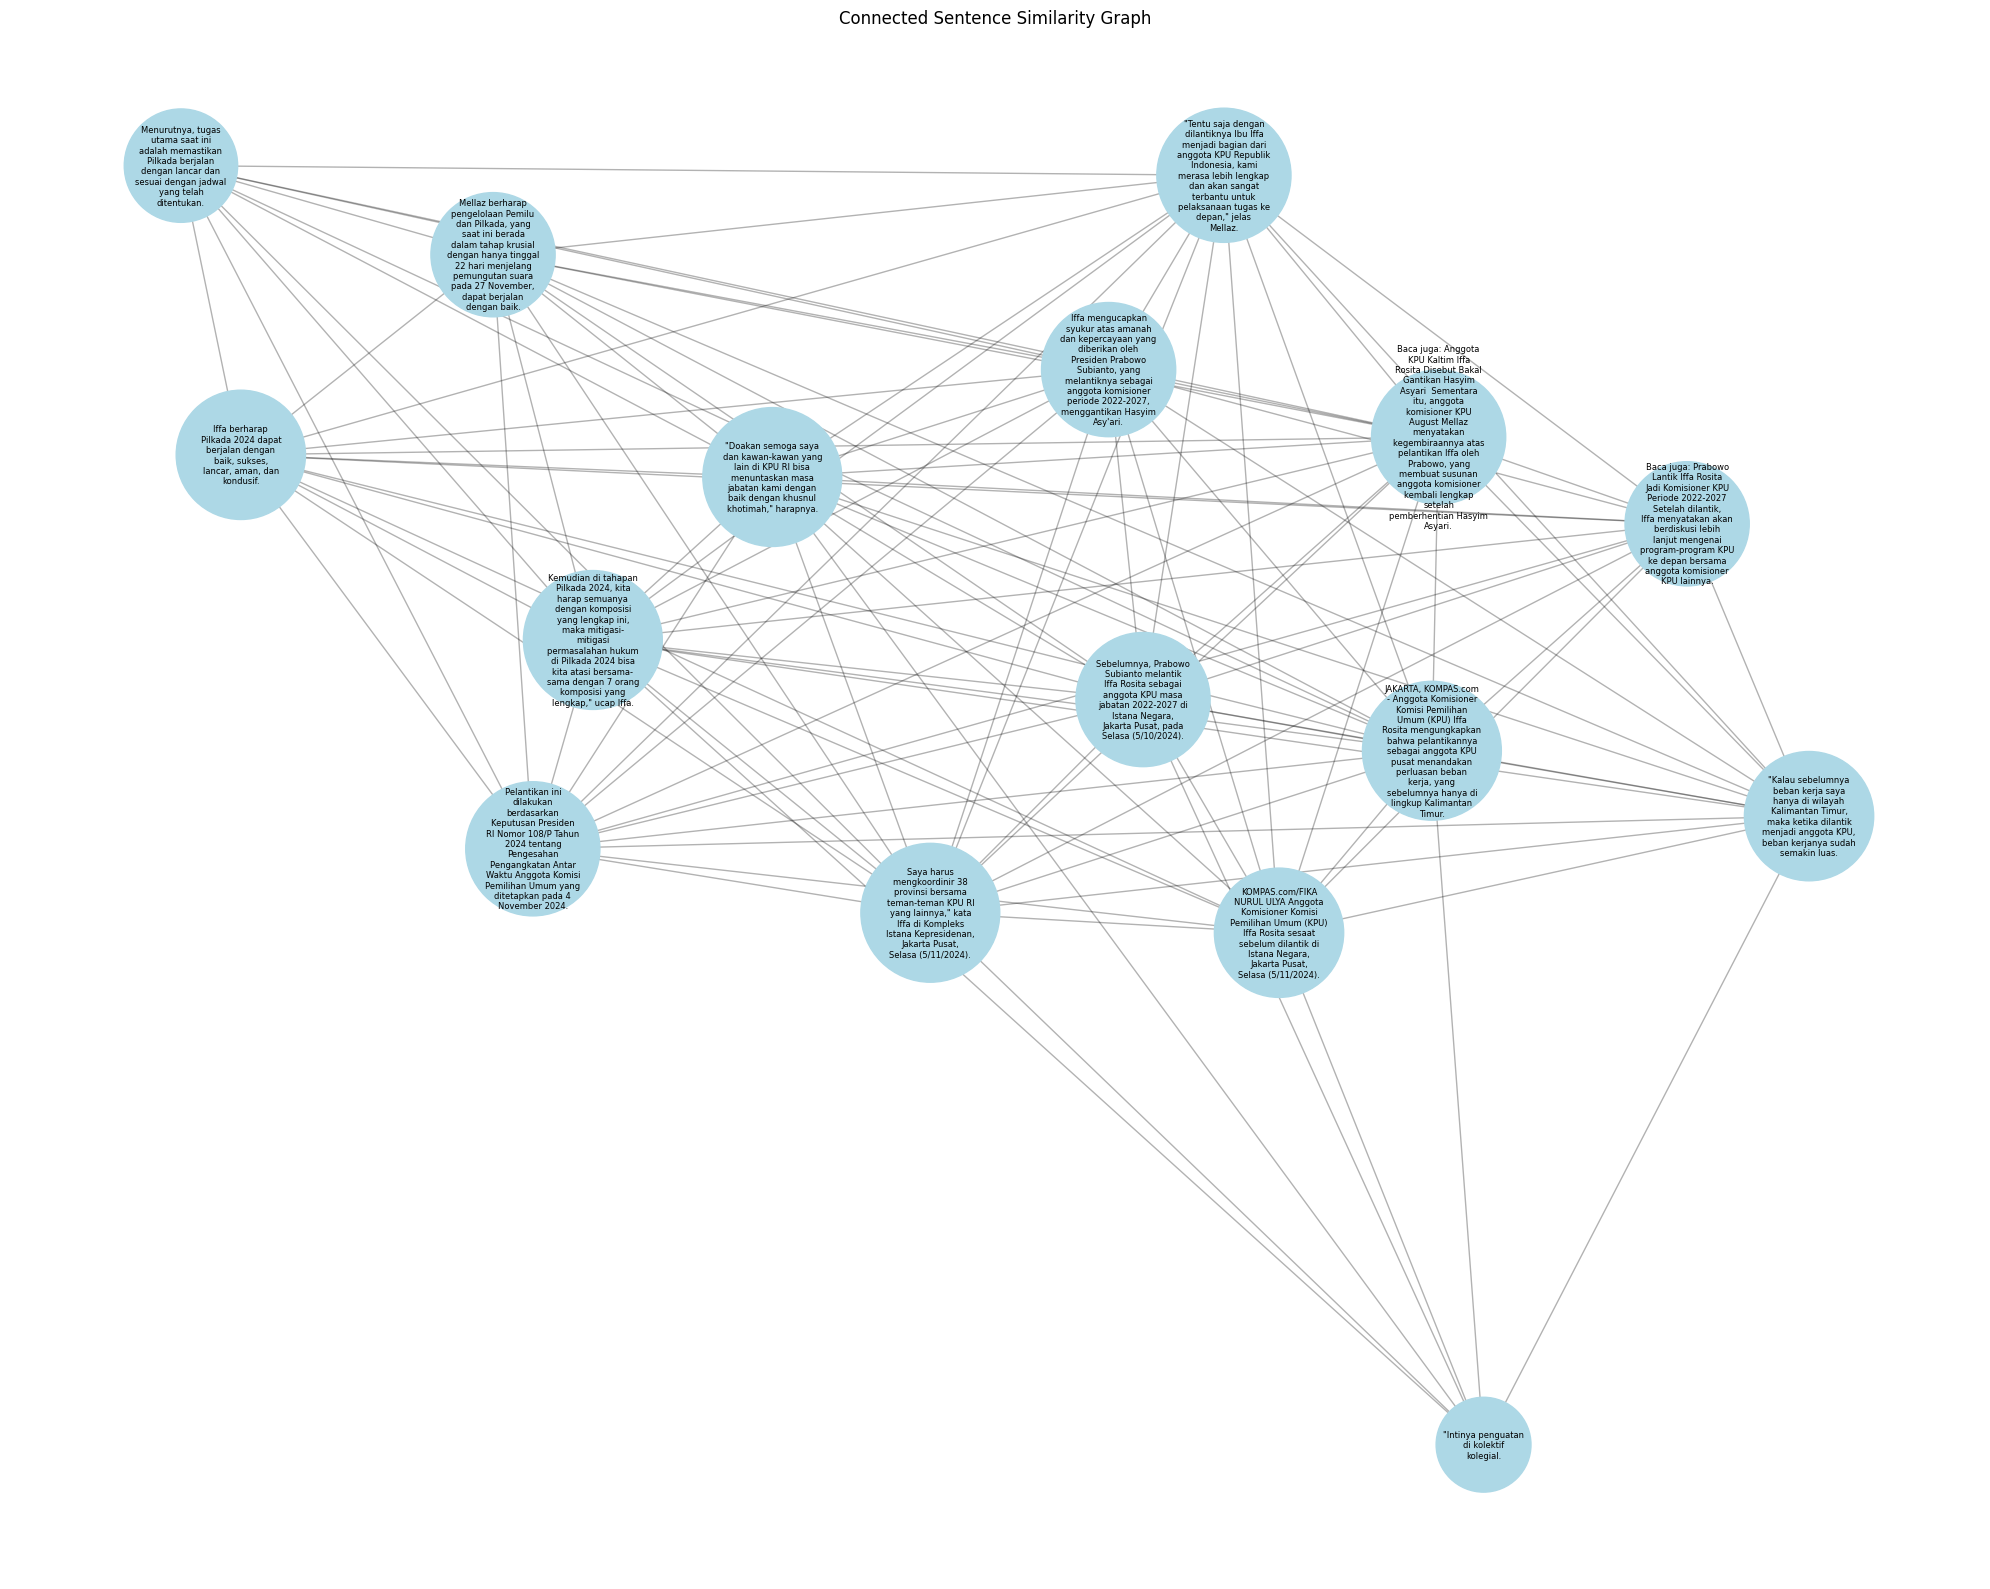

Number of nodes: 16
Number of edges: 105
Is the graph connected? True

Degree Centrality Measures:
                                             Sentence  Degree Centrality
0   "Doakan semoga saya dan kawan-kawan yang lain ...           1.000000
14  Saya harus mengkoordinir 38 provinsi bersama t...           1.000000
10  Kemudian di tahapan Pilkada 2024, kita harap s...           1.000000
8   JAKARTA, KOMPAS.com - Anggota Komisioner Komis...           1.000000
13  Pelantikan ini dilakukan berdasarkan Keputusan...           0.933333
3   "Tentu saja dengan dilantiknya Ibu Iffa menjad...           0.933333
7   Iffa mengucapkan syukur atas amanah dan keperc...           0.933333
4   Baca juga: Anggota KPU Kaltim Iffa Rosita Dise...           0.933333
15  Sebelumnya, Prabowo Subianto melantik Iffa Ros...           0.933333
9   KOMPAS.com/FIKA NURUL ULYA Anggota Komisioner ...           0.866667
2   "Kalau sebelumnya beban kerja saya hanya di wi...           0.866667
6   Iffa berharap Pilkada

In [50]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import textwrap

# Asumsi kita sudah memiliki tfidf_wide DataFrame dan kalimat-kalimat dari langkah sebelumnya
# Jika belum, jalankan terlebih dahulu kode perhitungan TF-IDF

# Menghitung cosine similarity
cosine_sim = cosine_similarity(tfidf_wide)

# Membuat DataFrame untuk matriks similarity
similarity_df = pd.DataFrame(cosine_sim, index=tfidf_wide.index, columns=tfidf_wide.index)

# Membuat graph dari matriks similarity
G = nx.from_pandas_adjacency(similarity_df)

# Menghapus self-loop
G.remove_edges_from(nx.selfloop_edges(G))

# Fungsi untuk mendapatkan komponen terhubung terbesar
def get_largest_component(G):
    return max(nx.connected_components(G), key=len)

# Memastikan graph terhubung
while not nx.is_connected(G):
    largest_component = get_largest_component(G)
    isolated_nodes = set(G.nodes()) - set(largest_component)
    if not isolated_nodes:
        break
    for node in isolated_nodes:
        similarities = [(other_node, similarity_df.loc[node, other_node]) 
                        for other_node in largest_component]
        most_similar_node = max(similarities, key=lambda x: x[1])[0]
        G.add_edge(node, most_similar_node)

# Fungsi untuk membungkus teks (kalimat)
def wrap_text(text, width=20):
    return '\n'.join(textwrap.wrap(text, width=width))

# Menyiapkan label (kalimat yang dibungkus)
labels = {node: wrap_text(node) for node in G.nodes()}

# Visualisasi graph
plt.figure(figsize=(20, 16))  # Ukuran figure yang lebih besar
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Menghitung ukuran node berdasarkan degree centrality
degree_centrality = nx.degree_centrality(G)
node_sizes = [v * 10000 for v in degree_centrality.values()]  # Ukuran node lebih besar

# Menggambar graph
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue')
nx.draw_networkx_edges(G, pos, alpha=0.3)

# Menambahkan label
nx.draw_networkx_labels(G, pos, labels, font_size=6)  # Ukuran font yang lebih kecil

plt.title("Connected Sentence Similarity Graph")
plt.axis('off')
plt.tight_layout()

# Menyimpan gambar graph
plt.savefig('connected_sentence_similarity_graph_degree_only.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()

# Menampilkan informasi tentang graph
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is the graph connected? {nx.is_connected(G)}")

# Membuat DataFrame hanya dengan degree centrality
degree_centrality_data = []
for node in G.nodes():
    degree_centrality_data.append({
        'Sentence': node,
        'Degree Centrality': degree_centrality[node]
    })

degree_centrality_df = pd.DataFrame(degree_centrality_data)

# Mengurutkan berdasarkan Degree Centrality
degree_centrality_df = degree_centrality_df.sort_values('Degree Centrality', ascending=False)

print("\nDegree Centrality Measures:")
print(degree_centrality_df)

# Menyimpan degree centrality ke dalam file CSV
degree_centrality_df.to_csv('degree_centrality_measures_with_sentences.csv', index=False)

# Opsional: Menampilkan top 5 kalimat berdasarkan Degree Centrality
print("\nTop 5 sentences by Degree Centrality:")
print(degree_centrality_df.nlargest(5, 'Degree Centrality')[['Sentence', 'Degree Centrality']])


DEPLOY : https://apptugas4merangkum.streamlit.app/
DEPLOY : https://huggingface.co/spaces/priob/tugas4merangkum